In [2]:
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. ĐỌC DỮ LIỆU GỐC
# ------------------------------------------------------------

FILE_PATH = '/content/bank.csv'
df = pd.read_csv(FILE_PATH)

print("===== 1. DỮ LIỆU GỐC =====")
print("Số dòng:", df.shape[0])
print("Số cột:", df.shape[1])

print("\nTên các cột:")
print(df.columns.tolist())

print("\n5 dòng đầu:")
display(df.head())

print("\nThông tin kiểu dữ liệu:")
df.info()

print("\nThống kê mô tả các biến số:")
display(df.describe())

print("\nThống kê mô tả các biến phân loại:")
display(df.describe(include="object"))

===== 1. DỮ LIỆU GỐC =====
Số dòng: 11162
Số cột: 17

Tên các cột:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'deposit']

5 dòng đầu:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes



Thông tin kiểu dữ liệu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB

Thống kê mô tả các biến số:


,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000



Thống kê mô tả các biến phân loại:


,job,marital,education,default,housing,loan,contact,month,poutcome,deposit
count,11162,11162,11162,11162,11162,11162,11162,11162,11162,11162
unique,12,3,4,2,2,2,3,12,4,2
top,management,married,secondary,no,no,no,cellular,may,unknown,no
freq,2566,6351,5476,10994,5881,9702,8042,2824,8326,5873


In [3]:
# ------------------------------------------------------------
# 2. KIỂM TRA TỔNG QUAN DỮ LIỆU GỐC
# ------------------------------------------------------------

print("\n===== 2. KIỂM TRA TỔNG QUAN DỮ LIỆU GỐC =====")

# Missing NaN/null
missing_df = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": (df.isna().sum() / len(df) * 100).round(2)
})

print("\nMissing NaN/null ở từng cột:")
display(missing_df)

print("\nTổng số missing NaN/null:", df.isna().sum().sum())

# Duplicate
print("\nSố dòng trùng lặp:", df.duplicated().sum())

# Target variable
target = "deposit"

print("\nPhân bố biến mục tiêu deposit:")
display(df[target].value_counts(dropna=False))

print("\nTỷ lệ biến mục tiêu deposit (%):")
display((df[target].value_counts(normalize=True, dropna=False) * 100).round(2))


===== 2. KIỂM TRA TỔNG QUAN DỮ LIỆU GỐC =====

Missing NaN/null ở từng cột:


,missing_count,missing_percent
age,0,0.0
job,0,0.0
marital,0,0.0
education,0,0.0
default,0,0.0
balance,0,0.0
housing,0,0.0
loan,0,0.0
contact,0,0.0
day,0,0.0



Tổng số missing NaN/null: 0

Số dòng trùng lặp: 0

Phân bố biến mục tiêu deposit:


,count
deposit,
no,5873
yes,5289



Tỷ lệ biến mục tiêu deposit (%):


,proportion
deposit,
no,52.62
yes,47.38


In [4]:
# ------------------------------------------------------------
# 3. KIỂM TRA GIÁ TRỊ UNKNOWN TRONG DỮ LIỆU GỐC
# ------------------------------------------------------------

print("\n===== 3. KIỂM TRA GIÁ TRỊ unknown TRONG DỮ LIỆU GỐC =====")

object_cols_raw = df.select_dtypes(include="object").columns

unknown_summary = []

for col in object_cols_raw:
    unknown_count = (
        df[col]
        .astype(str)
        .str.strip()
        .str.lower()
        .eq("unknown")
        .sum()
    )

    unknown_percent = round(unknown_count / len(df) * 100, 2)

    if unknown_count > 0:
        unknown_summary.append({
            "column": col,
            "unknown_count": unknown_count,
            "unknown_percent": unknown_percent
        })

unknown_df = pd.DataFrame(unknown_summary)

if len(unknown_df) > 0:
    print("\nCác cột có giá trị unknown:")
    display(unknown_df)
else:
    print("Không có giá trị unknown.")


===== 3. KIỂM TRA GIÁ TRỊ unknown TRONG DỮ LIỆU GỐC =====

Các cột có giá trị unknown:


,column,unknown_count,unknown_percent
0,job,70,0.63
1,education,497,4.45
2,contact,2346,21.02
3,poutcome,8326,74.59


Sau khi kiểm tra được tỷ lệ phần trăm của giá trị unknow của từng biến, nhóm sẽ đưa ra cách xử lý giá trị "unknown" theo các phương pháp phù hợp

In [5]:
# ------------------------------------------------------------
# 4. CHUẨN HÓA TÊN CỘT
# ------------------------------------------------------------

df_clean = df.copy()

print("\n===== 4. CHUẨN HÓA TÊN CỘT =====")
# Đưa tên cột về chữ thường, xóa khoảng trắng thừa, thay khoảng trắng bằng dấu gạch dưới.
df_clean.columns = (
    df_clean.columns
    .str.strip()
    .str.lower()
    .str.replace(r"\s+", "_", regex=True)
)

print("Tên cột sau khi chuẩn hóa:")
print(df_clean.columns.tolist())



===== 4. CHUẨN HÓA TÊN CỘT =====
Tên cột sau khi chuẩn hóa:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'deposit']


In [6]:
# ------------------------------------------------------------
# 5. CHUẨN HÓA DỮ LIỆU DẠNG CHỮ
# ------------------------------------------------------------

print("\n===== 5. CHUẨN HÓA DỮ LIỆU DẠNG CHỮ =====")

object_cols = df_clean.select_dtypes(include="object").columns
# Xóa khoảng trắng thừa trong các cột dạng chữ, đưa toàn bộ giá trị chữ về chữ thường.
for col in object_cols:
    df_clean[col] = (
        df_clean[col]
        .astype(str)
        .str.strip()
        .str.lower()
    )
display(df_clean.head())




===== 5. CHUẨN HÓA DỮ LIỆU DẠNG CHỮ =====


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [7]:
# ------------------------------------------------------------
# 6. CHUẨN HÓA NHÃN CATEGORY
# ------------------------------------------------------------

print("\n===== 6. CHUẨN HÓA NHÃN CATEGORY =====")

# Chuẩn hóa các nhãn có dấu chấm, dấu gạch ngang
if "job" in df_clean.columns:
    df_clean["job"] = df_clean["job"].replace({
        "admin.": "admin",
        "blue-collar": "blue_collar",
        "self-employed": "self_employed"
    })

print("Giá trị cột job sau khi chuẩn hóa:")
display(df_clean["job"].value_counts(dropna=False))



===== 6. CHUẨN HÓA NHÃN CATEGORY =====
Giá trị cột job sau khi chuẩn hóa:


,count
job,
management,2566
blue_collar,1944
technician,1823
admin,1334
services,923
retired,778
self_employed,405
student,360
unemployed,357


In [8]:
# ------------------------------------------------------------
# 7. MÃ HÓA CÁC BIẾN YES/NO THÀNH 1/0
# ------------------------------------------------------------

print("\n===== 7. MÃ HÓA CÁC BIẾN YES/NO THÀNH 1/0 =====")

binary_cols = ["default", "housing", "loan", "deposit"]

for col in binary_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].map({
            "yes": 1,
            "no": 0
        })

for col in binary_cols:
    if col in df_clean.columns:
        print(f"\nPhân bố cột {col} sau mã hóa:")
        display(df_clean[col].value_counts(dropna=False))


===== 7. MÃ HÓA CÁC BIẾN YES/NO THÀNH 1/0 =====

Phân bố cột default sau mã hóa:


,count
default,
0,10994
1,168



Phân bố cột housing sau mã hóa:


,count
housing,
0,5881
1,5281



Phân bố cột loan sau mã hóa:


,count
loan,
0,9702
1,1460



Phân bố cột deposit sau mã hóa:


,count
deposit,
0,5873
1,5289


Các biến dạng yes/no được mã hóa thành 1/0.
Trong đó, deposit là biến mục tiêu:
1 = khách hàng đăng ký tiền gửi có kỳ hạn
0 = khách hàng không đăng ký

In [9]:
# ------------------------------------------------------------
# 8. TẠO BIẾN month_num
# ------------------------------------------------------------

print("\n===== 8. TẠO BIẾN month_num =====")

month_map = {
    "jan": 1,
    "feb": 2,
    "mar": 3,
    "apr": 4,
    "may": 5,
    "jun": 6,
    "jul": 7,
    "aug": 8,
    "sep": 9,
    "oct": 10,
    "nov": 11,
    "dec": 12
}

if "month" in df_clean.columns:
    df_clean["month_num"] = df_clean["month"].map(month_map)

print("Kiểm tra month và month_num:")
display(df_clean[["month", "month_num"]].head())

print("\nPhân bố month_num:")
display(df_clean["month_num"].value_counts(dropna=False).sort_index())



===== 8. TẠO BIẾN month_num =====
Kiểm tra month và month_num:


,month,month_num
0,may,5
1,may,5
2,may,5
3,may,5
4,may,5



Phân bố month_num:


,count
month_num,
1,344
2,776
3,276
4,923
5,2824
6,1222
7,1514
8,1519
9,319


Cột month ban đầu ở dạng chữ nên nhóm tạo thêm month_num để thuận tiện cho phân tích.
Nhóm vẫn giữ lại month gốc để phục vụ trực quan hóa theo tháng trong bước EDA.

In [10]:
# ------------------------------------------------------------
# 9. XỬ LÝ BIẾN pdays
# ------------------------------------------------------------

print("\n===== 9. XỬ LÝ BIẾN pdays =====")

print("Giá trị nhỏ nhất của pdays trước xử lý:", df_clean["pdays"].min())
print("Số lượng pdays = -1:", (df_clean["pdays"] == -1).sum())

# pdays = -1 nghĩa là khách hàng chưa từng được liên hệ trước đó.
df_clean["was_contacted_before"] = np.where(df_clean["pdays"] == -1, 0, 1)

# Tạo biến pdays_clean để loại bỏ giá trị âm đặc biệt.
df_clean["pdays_clean"] = df_clean["pdays"].replace(-1, 0)

print("\nKiểm tra pdays sau xử lý:")
display(df_clean[["pdays", "was_contacted_before", "pdays_clean"]].head(10))

print("\nPhân bố was_contacted_before:")
display(df_clean["was_contacted_before"].value_counts(dropna=False))


===== 9. XỬ LÝ BIẾN pdays =====
Giá trị nhỏ nhất của pdays trước xử lý: -1
Số lượng pdays = -1: 8324

Kiểm tra pdays sau xử lý:


,pdays,was_contacted_before,pdays_clean
0,-1,0,0
1,-1,0,0
2,-1,0,0
3,-1,0,0
4,-1,0,0
5,-1,0,0
6,-1,0,0
7,-1,0,0
8,-1,0,0
9,-1,0,0



Phân bố was_contacted_before:


,count
was_contacted_before,
0,8324
1,2838


pdays = -1 không phải lỗi dữ liệu mà là giá trị đặc biệt.
Giá trị này thể hiện khách hàng chưa từng được liên hệ trong chiến dịch trước.
Vì vậy, nhóm không xóa mà tách thành:
- was_contacted_before: khách hàng đã từng được liên hệ hay chưa
- pdays_clean: thay -1 bằng 0 để tránh giá trị âm gây nhiễu khi phân tích

In [11]:
# ============================================================
# 10. ÉP KIỂU DỮ LIỆU
# ============================================================

print("\n===== 10. ÉP KIỂU DỮ LIỆU =====")

int_cols = [
    "age",
    "default",
    "balance",
    "housing",
    "loan",
    "day",
    "duration",
    "campaign",
    "pdays",
    "previous",
    "deposit",
    "month_num",
    "was_contacted_before",
    "pdays_clean"
]

for col in int_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].astype("int64")

print("Kiểu dữ liệu sau khi ép kiểu:")
display(df_clean.dtypes)


===== 10. ÉP KIỂU DỮ LIỆU =====
Kiểu dữ liệu sau khi ép kiểu:


,0
age,int64
job,object
marital,object
education,object
default,int64
balance,int64
housing,int64
loan,int64
contact,object
day,int64


In [12]:
# ============================================================
# 11 XỬ LÝ UNKNOWN
# ============================================================

print("\n===== 11. XỬ LÝ UNKNOWN  =====")

# Trong dataset này không có missing dạng NaN/null,
# nhưng có giá trị 'unknown' ở một số biến phân loại.
# Nhóm xem 'unknown' là dạng dữ liệu thiếu đặc biệt.

# Với job và education: Nhóm dùng Imputation bằng mode để thay thế.

impute_unknown_cols = ["job", "education"]

imputation_summary = []

for col in impute_unknown_cols:
    if col in df_clean.columns:
        unknown_before = df_clean[col].eq("unknown").sum()

        if unknown_before > 0:
            mode_value = df_clean.loc[df_clean[col] != "unknown", col].mode()[0]

            df_clean[col] = df_clean[col].replace("unknown", mode_value)

            unknown_after = df_clean[col].eq("unknown").sum()

            imputation_summary.append({
                "column": col,
                "method": "mode imputation",
                "mode_value": mode_value,
                "unknown_before": unknown_before,
                "unknown_after": unknown_after
            })

# Với contact và poutcome:
# Không thay bằng mode vì unknown ở hai cột này có thể có ý nghĩa nghiệp vụ.
# Do đó nhóm giữ lại unknown như một nhóm riêng để tránh làm sai lệch dữ liệu.

keep_unknown_cols = ["contact", "poutcome"]

for col in keep_unknown_cols:
    if col in df_clean.columns:
        unknown_count = df_clean[col].eq("unknown").sum()

        if unknown_count > 0:
            imputation_summary.append({
                "column": col,
                "method": "keep as category",
                "mode_value": "not applied",
                "unknown_before": unknown_count,
                "unknown_after": unknown_count
            })

imputation_summary_df = pd.DataFrame(imputation_summary)

display(imputation_summary_df)


===== 11. XỬ LÝ UNKNOWN  =====


,column,method,mode_value,unknown_before,unknown_after
0,job,mode imputation,management,70,0
1,education,mode imputation,secondary,497,0
2,contact,keep as category,not applied,2346,2346
3,poutcome,keep as category,not applied,8326,8326


Nhóm xử lý unknown theo đặc điểm của từng biến.
Với job và education, nhóm dùng imputation bằng mode.
Với contact và poutcome, nhóm giữ unknown như một nhóm riêng vì giá trị này có thể mang ý nghĩa nghiệp vụ.
Nhóm không sử dụng prediction vì phương pháp này phức tạp hơn và chưa phù hợp với phạm vi bài học hiện tại.

In [13]:
# ============================================================
# 12. KIỂM TRA OUTLIERS BẰNG IQR
# ============================================================

print("\n===== 12. KIỂM TRA OUTLIERS BẰNG IQR =====")

numeric_cols = [
    "age",
    "balance",
    "day",
    "duration",
    "campaign",
    "pdays",
    "pdays_clean",
    "previous",
    "month_num"
]

outlier_summary = []

for col in numeric_cols:
    if col in df_clean.columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outlier_count = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
        outlier_percent = round(outlier_count / len(df_clean) * 100, 2)

        outlier_summary.append({
            "column": col,
            "min": df_clean[col].min(),
            "max": df_clean[col].max(),
            "Q1": Q1,
            "Q3": Q3,
            "IQR": IQR,
            "lower_bound": lower,
            "upper_bound": upper,
            "outlier_count": outlier_count,
            "outlier_percent": outlier_percent
        })

outlier_df = pd.DataFrame(outlier_summary)

display(outlier_df.sort_values("outlier_count", ascending=False))


===== 12. KIỂM TRA OUTLIERS BẰNG IQR =====


,column,min,max,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count,outlier_percent
6,pdays_clean,0,854,0.0,20.75,20.75,-31.125,51.875,2754,24.67
5,pdays,-1,854,-1.0,20.75,21.75,-33.625,53.375,2750,24.64
7,previous,0,58,0.0,1.00,1.00,-1.500,2.500,1258,11.27
1,balance,-6847,81204,122.0,1708.00,1586.00,-2257.000,4087.000,1055,9.45
3,duration,2,3881,138.0,496.00,358.00,-399.000,1033.000,636,5.70
4,campaign,1,63,1.0,3.00,2.00,-2.000,6.000,601,5.38
0,age,18,95,32.0,49.00,17.00,6.500,74.500,171,1.53
2,day,1,31,8.0,22.00,14.00,-13.000,43.000,0,0.00
8,month_num,1,12,5.0,8.00,3.00,0.500,12.500,0,0.00


Nhóm sử dụng phương pháp IQR để kiểm tra các giá trị ngoại lệ trong các biến số.
Kết quả kiểm tra giúp xác định những biến có nhiều giá trị nằm ngoài ngưỡng Q1 - 1.5*IQR
và Q3 + 1.5*IQR.
Sau bước phát hiện, nhóm lựa chọn xử lý outliers ở một số biến phù hợp bằng median imputation.
Các biến có ý nghĩa logic hoặc thời gian như pdays, pdays_clean, day và month_num không được thay thế.

In [14]:
# ============================================================
# 13. XỬ LÝ OUTLIERS BẰNG MEDIAN IMPUTATION
# ============================================================

print("\n===== 13. XỬ LÝ OUTLIERS BẰNG MEDIAN IMPUTATION =====")

# Nhóm xử lý outliers bằng cách thay thế các giá trị ngoại lệ bằng median.

outlier_cols_to_impute = [
    "age",
    "balance",
    "duration",
    "campaign",
    "previous"
]

outlier_treatment_summary = []

for col in outlier_cols_to_impute:
    if col in df_clean.columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        median_value = df_clean[col].median()

        outlier_mask = (
            (df_clean[col] < lower_bound) |
            (df_clean[col] > upper_bound)
        )

        outlier_before = outlier_mask.sum()

        before_min = df_clean[col].min()
        before_max = df_clean[col].max()

        # Thay outlier bằng median
        df_clean.loc[outlier_mask, col] = median_value

        after_min = df_clean[col].min()
        after_max = df_clean[col].max()

        outlier_treatment_summary.append({
            "column": col,
            "method": "median imputation",
            "median_value": median_value,
            "lower_bound": lower_bound,
            "upper_bound": upper_bound,
            "outlier_before": outlier_before,
            "before_min": before_min,
            "before_max": before_max,
            "after_min": after_min,
            "after_max": after_max
        })

outlier_treatment_df = pd.DataFrame(outlier_treatment_summary)

display(outlier_treatment_df)


===== 13. XỬ LÝ OUTLIERS BẰNG MEDIAN IMPUTATION =====


,column,method,median_value,lower_bound,upper_bound,outlier_before,before_min,before_max,after_min,after_max
0,age,median imputation,39.0,6.5,74.5,171,18,95,18,74
1,balance,median imputation,550.0,-2257.0,4087.0,1055,-6847,81204,-2049,4087
2,duration,median imputation,255.0,-399.0,1033.0,636,2,3881,2,1033
3,campaign,median imputation,2.0,-2.0,6.0,601,1,63,1,6
4,previous,median imputation,0.0,-1.5,2.5,1258,0,58,0,2


Sau khi phát hiện outliers bằng phương pháp IQR, nhóm xử lý các giá trị ngoại lệ
ở một số biến số bằng phương pháp median imputation.
Median được lựa chọn vì ít bị ảnh hưởng bởi các giá trị quá lớn hoặc quá nhỏ,
phù hợp hơn mean trong trường hợp dữ liệu có ngoại lệ.

In [15]:
# ============================================================
# 14. DATA QUALITY CHECK SAU LÀM SẠCH
# ============================================================

print("\n===== 14. DATA QUALITY CHECK SAU LÀM SẠCH =====")

errors = []

# 1. Missing NaN/null
missing = df_clean.isna().sum()

if missing.sum() > 0:
    errors.append("Còn missing NaN/null")

# 2. Duplicate
duplicate_count = df_clean.duplicated().sum()

if duplicate_count > 0:
    errors.append("Còn dòng trùng lặp")

# 3. Range check
if "age" in df_clean.columns:
    if not df_clean["age"].between(18, 100).all():
        errors.append("age có giá trị ngoài khoảng 18-100")

if "day" in df_clean.columns:
    if not df_clean["day"].between(1, 31).all():
        errors.append("day có giá trị ngoài khoảng 1-31")

if "month_num" in df_clean.columns:
    if not df_clean["month_num"].between(1, 12).all():
        errors.append("month_num có giá trị ngoài khoảng 1-12")

if "duration" in df_clean.columns:
    if (df_clean["duration"] < 0).any():
        errors.append("duration có giá trị âm")

if "campaign" in df_clean.columns:
    if (df_clean["campaign"] < 1).any():
        errors.append("campaign có giá trị nhỏ hơn 1")

if "previous" in df_clean.columns:
    if (df_clean["previous"] < 0).any():
        errors.append("previous có giá trị âm")

if "pdays_clean" in df_clean.columns:
    if (df_clean["pdays_clean"] < 0).any():
        errors.append("pdays_clean có giá trị âm")

# 4. Binary check
for col in ["default", "housing", "loan", "deposit", "was_contacted_before"]:
    if col in df_clean.columns:
        values = set(df_clean[col].dropna().unique())

        if not values.issubset({0, 1}):
            errors.append(f"{col} không phải dạng 0/1")

# 5. Category check
allowed_categories = {
    "job": {
        "admin", "technician", "services", "management", "retired",
        "blue_collar", "unemployed", "entrepreneur", "housemaid",
        "self_employed", "student"
    },
    "marital": {"married", "single", "divorced"},
    "education": {"secondary", "tertiary", "primary"},
    "contact": {"unknown", "cellular", "telephone"},
    "month": {
        "jan", "feb", "mar", "apr", "may", "jun",
        "jul", "aug", "sep", "oct", "nov", "dec"
    },
    "poutcome": {"unknown", "other", "failure", "success"}
}

for col, allowed in allowed_categories.items():
    if col in df_clean.columns:
        current_values = set(df_clean[col].dropna().unique())
        unexpected_values = current_values - allowed

        if unexpected_values:
            errors.append(f"{col} có giá trị lạ: {unexpected_values}")

# 6. Logic pdays
if {"pdays", "was_contacted_before", "pdays_clean"}.issubset(df_clean.columns):

    bad_pdays = df_clean[
        ((df_clean["pdays"] == -1) & (df_clean["was_contacted_before"] != 0)) |
        ((df_clean["pdays"] != -1) & (df_clean["was_contacted_before"] != 1)) |
        ((df_clean["pdays"] == -1) & (df_clean["pdays_clean"] != 0)) |
        ((df_clean["pdays"] != -1) & (df_clean["pdays_clean"] != df_clean["pdays"]))
    ]

    if len(bad_pdays) > 0:
        errors.append("Logic pdays, was_contacted_before hoặc pdays_clean bị sai")
# 7. In kết quả
print("\nKết quả kiểm tra chất lượng dữ liệu:")

if len(errors) == 0:
    print("PASSED - Dữ liệu đạt tiêu chí sạch cho bước EDA/báo cáo.")
else:
    print("FAILED - Dữ liệu còn lỗi:")
    for error in errors:
        print("-", error)

print("\nTổng missing NaN/null sau làm sạch:", df_clean.isna().sum().sum())
print("Số dòng trùng sau làm sạch:", df_clean.duplicated().sum())


===== 14. DATA QUALITY CHECK SAU LÀM SẠCH =====

Kết quả kiểm tra chất lượng dữ liệu:
PASSED - Dữ liệu đạt tiêu chí sạch cho bước EDA/báo cáo.

Tổng missing NaN/null sau làm sạch: 0
Số dòng trùng sau làm sạch: 0


In [16]:
df_clean.to_csv('/content/cleaned_data.csv', index=False)
print("Dữ liệu sạch đã được xuất ra file 'cleaned_data.csv' trong thư mục /content của Colab.")

Dữ liệu sạch đã được xuất ra file 'cleaned_data.csv' trong thư mục /content của Colab.


## Phần 1: Kiểm tra và Hợp nhất (Data Integration)

Trước khi phân tích sâu, cần đảm bảo các "mảnh ghép" dữ liệu khớp nhau:

*   **Tính nhất quán**: Kiểm tra các file (ví dụ: doanh số các tháng) có đồng nhất về cấu trúc cột hay không.
*   **Mối quan hệ**: Xác định các khóa (Primary Key - Foreign Key) để kết nối các bảng với nhau. Ví dụ: Khách hàng (customers.csv) với bảng Đơn hàng (orders.csv).
*   **Tự động hóa**: Sử dụng `pd.concat()` hoặc `pd.merge()` để gộp dữ liệu thay vì thao tác thủ công nhằm tránh sai sót.

In [17]:
# YÊU CẦU 1 — KIỂM TRA VÀ HỢP NHẤT (Data Integration)
# ============================================================
print("=" * 60)
print("YÊU CẦU 1: KIỂM TRA VÀ HỢP NHẤT DỮ LIỆU")
print("=" * 60)

# --- 1.1 Đọc dữ liệu ---
df = pd.read_csv(FILE_PATH)
print(f"\n[1.1] Đọc file thành công: {df.shape[0]:,} dòng × {df.shape[1]} cột")

# Convert 'deposit' column to numeric before further analysis in this cell
df['deposit'] = df['deposit'].map({"yes": 1, "no": 0})

# --- 1.2 Kiểm tra cấu trúc cột ---
print("\n[1.2] Danh sách cột và kiểu dữ liệu:")
print(df.dtypes.to_string())

# --- 1.3 Kiểm tra tính nhất quán (missing values) ---
print("\n[1.3] Kiểm tra Missing Values:")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Số lượng NaN': missing, 'Tỷ lệ (%)': missing_pct})
print(missing_df[missing_df['Số lượng NaN'] > 0] if missing.sum() > 0 else "Không có missing value!")

# --- 1.4 Kiểm tra dữ liệu trùng lặp ---
duplicates = df.duplicated().sum()
print(f"\n[1.4] Dữ liệu trùng lặp: {duplicates} dòng")
if duplicates > 0:
    df = df.drop_duplicates()
    print(f"  → Đã xóa. Còn lại: {len(df):,} dòng")

# --- 1.5 Xác định Primary Key tiềm năng ---
print("\n[1.5] Kiểm tra tính duy nhất của từng cột (Primary Key):")
for col in df.columns:
    unique_pct = df[col].nunique() / len(df) * 100
    if unique_pct == 100:
        print(f"'{col}' có thể là Primary Key (100% unique)")

# --- 1.6 Thống kê mô tả tổng quan ---
print("\n[1.6] Thống kê mô tả (numeric):")
print(df.describe().round(2).to_string())

# --- 1.7 Phân phối biến mục tiêu (deposit) ---
print("\n[1.7] Phân phối biến mục tiêu 'deposit':")
deposit_counts = df['deposit'].value_counts()
deposit_pct = df['deposit'].value_counts(normalize=True) * 100
for val in deposit_counts.index:
    label = "Mở deposit" if val == 1 else "Không mở"
    print(f"  {label} ({val}): {deposit_counts[val]:,} ({deposit_pct[val]:.1f}%)")

# --- 1.8 Ví dụ pd.concat (giả lập hợp nhất 2 tháng) ---
print("\n[1.8] Ví dụ pd.concat — hợp nhất dữ liệu theo tháng:")
df_may = df[df['month'] == 'may'].copy()
df_jun = df[df['month'] == 'jun'].copy()
df_merged_concat = pd.concat([df_may, df_jun], ignore_index=True)
print(f"  Tháng 5: {len(df_may):,} dòng | Tháng 6: {len(df_jun):,} dòng")
print(f"  Sau pd.concat: {len(df_merged_concat):,} dòng")

# --- 1.9 Ví dụ pd.merge (join theo khóa) ---
print("\n[1.9] Ví dụ pd.merge — kết hợp bảng job summary vào bảng chính:")
job_summary = df.groupby('job')['deposit'].mean().reset_index()
job_summary.columns = ['job', 'deposit_rate_by_job']
df_with_job_rate = pd.merge(df, job_summary, on='job', how='left')
print(f"  Bảng gốc: {df.shape} → Sau merge: {df_with_job_rate.shape}")
print("  5 dòng đầu (thêm cột deposit_rate_by_job):")
print(df_with_job_rate[['job', 'deposit', 'deposit_rate_by_job']].head())

YÊU CẦU 1: KIỂM TRA VÀ HỢP NHẤT DỮ LIỆU

[1.1] Đọc file thành công: 11,162 dòng × 17 cột

[1.2] Danh sách cột và kiểu dữ liệu:
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
deposit       int64

[1.3] Kiểm tra Missing Values:
Không có missing value!

[1.4] Dữ liệu trùng lặp: 0 dòng

[1.5] Kiểm tra tính duy nhất của từng cột (Primary Key):

[1.6] Thống kê mô tả (numeric):
            age   balance       day  duration  campaign     pdays  previous   deposit
count  11162.00  11162.00  11162.00  11162.00  11162.00  11162.00  11162.00  11162.00
mean      41.23   1528.54     15.66    371.99      2.51     51.33      0.83      0.47
std       11.91   3225.41      8.42    347.13      2.72    108.76      2.29      0.50
min      

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập phong cách đồ họa theo chuẩn Seaborn để biểu đồ trực quan, chuyên nghiệp hơn
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6) # Kích thước mặc định

# Đọc dữ liệu đã làm sạch
df_clean = pd.read_csv('/content/cleaned_data.csv')

# Kiểm tra nhanh kiểu dữ liệu cột target
print("Tỷ lệ phân bổ của biến mục tiêu (deposit):")
print(df_clean['deposit'].value_counts(normalize=True) * 100)

Tỷ lệ phân bổ của biến mục tiêu (deposit):
deposit
0    52.616019
1    47.383981
Name: proportion, dtype: float64


2. **PHÂN TÍCH KHÁM PHÁ (EDA - Exploratory Data Analysis)**

2.1. Phân bổ và Ngoại lệ (Boxplot & Histogram)
Theo lý thuyết, trực quan hóa đóng vai trò khám phá dữ liệu để xác định điểm ngoại lai và xem xét các phép biến đổi. Bước này giúp ta kiểm chứng xem việc làm sạch outliers trước đó đã hiệu quả chưa.


--- 1. PHÂN BỔ VÀ NGOẠI LỆ ---


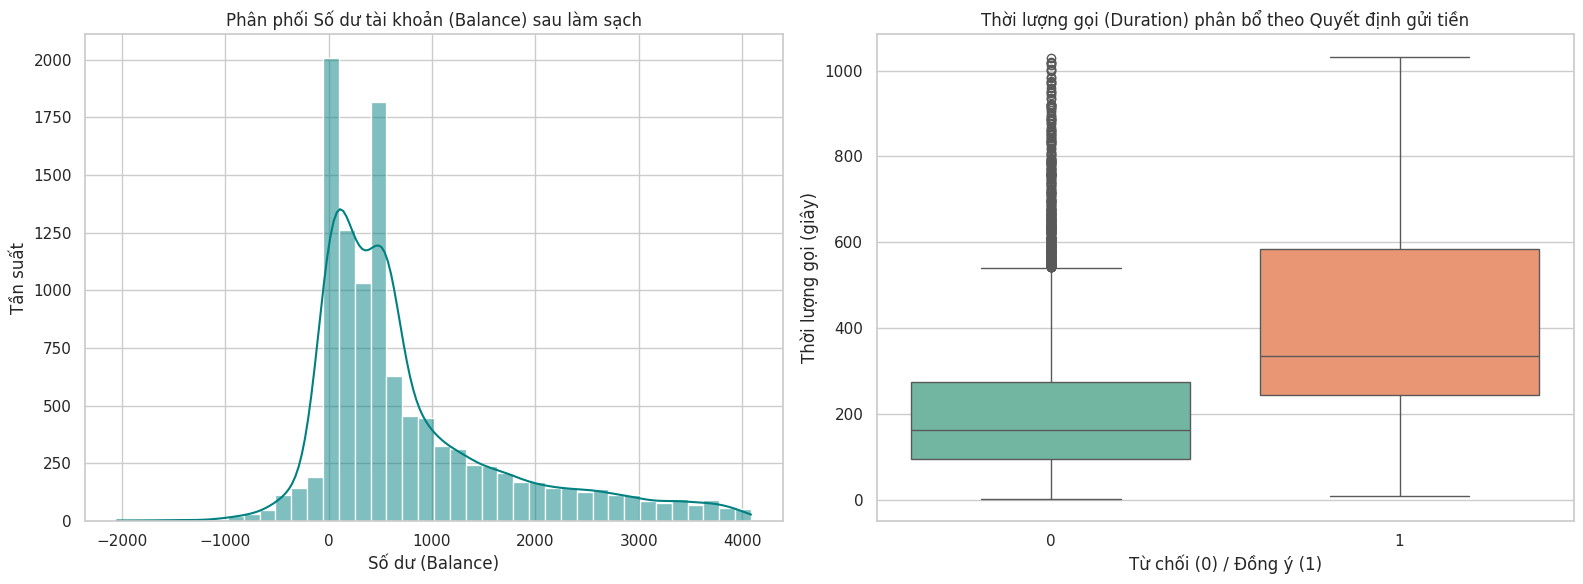

In [19]:
print("\n--- 1. PHÂN BỔ VÀ NGOẠI LỆ ---")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram: Phân bổ số dư tài khoản
sns.histplot(df_clean['balance'], bins=40, kde=True, ax=axes[0], color='teal')
axes[0].set_title('Phân phối Số dư tài khoản (Balance) sau làm sạch')
axes[0].set_xlabel('Số dư (Balance)')
axes[0].set_ylabel('Tần suất')

# Boxplot: Đánh giá thời lượng gọi theo quyết định gửi tiền
sns.boxplot(x='deposit', y='duration', data=df_clean, ax=axes[1], palette='Set2', hue='deposit', legend=False)
axes[1].set_title('Thời lượng gọi (Duration) phân bổ theo Quyết định gửi tiền')
axes[1].set_xlabel('Từ chối (0) / Đồng ý (1)')
axes[1].set_ylabel('Thời lượng gọi (giây)')

plt.tight_layout()
plt.show()

Histogram (balance): Biểu đồ này giúp nhóm kiểm chứng bước làm sạch dữ liệu trước đó. Đường cong KDE (Kernel Density Estimate) cho thấy dữ liệu số dư đã tập trung mượt mà hơn, không còn bị kéo giãn bất thường bởi những giá trị quá lớn (outliers siêu giàu).

Boxplot (duration): Biểu đồ hộp thể hiện trung vị (đường gạch ngang ở giữa hộp) và các tứ phân vị. Rất rõ ràng, nhóm khách hàng đồng ý (deposit=1) có trung vị thời lượng cuộc gọi cao hơn hẳn nhóm từ chối (deposit=0).

# 2.2 Kiểm định giả thuyết

 Nhóm xác định rõ câu hỏi nghiên cứu trung tâm mà toàn bộ dự án hướng đến:
"Liệu có thể dự đoán khách hàng nào sẽ đăng ký tiền gửi có kỳ hạn — dựa trên đặc điểm nhân khẩu học và hành vi trong chiến dịch gọi điện của ngân hàng?"

**2.2.1: Về Nhân khẩu học (Bar Chart)**
Sử dụng Biểu đồ cột (Bar Chart) để so sánh hiệu suất (tỷ lệ đăng ký) giữa các nhóm danh mục.


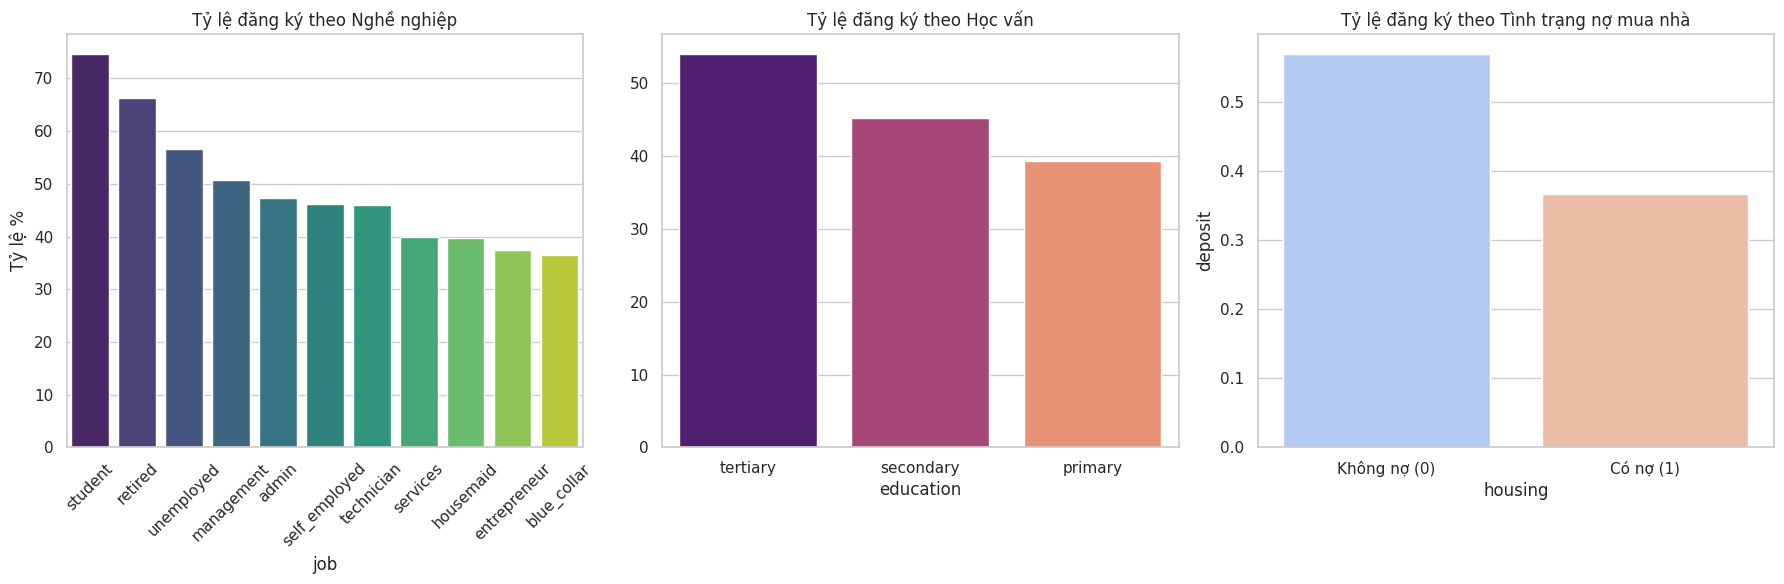

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Nghề nghiệp (Job) vs Deposit
job_deposit = df_clean.groupby('job')['deposit'].mean().sort_values(ascending=False) * 100
sns.barplot(x=job_deposit.index, y=job_deposit.values, palette='viridis', ax=axes[0], hue=job_deposit.index, legend=False)
axes[0].set_title('Tỷ lệ đăng ký theo Nghề nghiệp')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylabel('Tỷ lệ %')

# 2. Học vấn (Education) vs Deposit
edu_deposit = df_clean.groupby('education')['deposit'].mean().sort_values(ascending=False) * 100
sns.barplot(x=edu_deposit.index, y=edu_deposit.values, palette='magma', ax=axes[1], hue=edu_deposit.index, legend=False)
axes[1].set_title('Tỷ lệ đăng ký theo Học vấn')

# 3. Tình trạng Nợ (Housing Loan) vs Deposit
sns.barplot(x='housing', y='deposit', data=df_clean, errorbar=None, palette='coolwarm', ax=axes[2], hue='housing', legend=False)
axes[2].set_title('Tỷ lệ đăng ký theo Tình trạng nợ mua nhà')
axes[2].set_xticks([0, 1]) # Explicitly set ticks before setting labels
axes[2].set_xticklabels(['Không nợ (0)', 'Có nợ (1)'])

plt.tight_layout()
plt.show()

Giả thuyết Nghề nghiệp: ĐÚNG. Biểu đồ sẽ cho thấy cột student (học sinh) và retired (nghỉ hưu) có tỷ lệ % cao vượt trội so với nhóm blue-collar hay services.

Giả thuyết Học vấn: ĐÚNG. Nhóm tertiary (Đại học/Cao đẳng) có tỷ lệ đăng ký cao nhất.

Giả thuyết Nợ: ĐÚNG. Những người "Không nợ" (housing = 0) có tỷ lệ tham gia gửi tiền cao hơn hẳn người đang cõng nợ.

2.2.2: Hành vi trong chiến dịch (Scatter Plot & Bar Chart)
Sử dụng Biểu đồ tán xạ (Scatter Plot) để tìm mối quan hệ giữa hai biến định lượng và Bar Chart cho biến quá khứ.

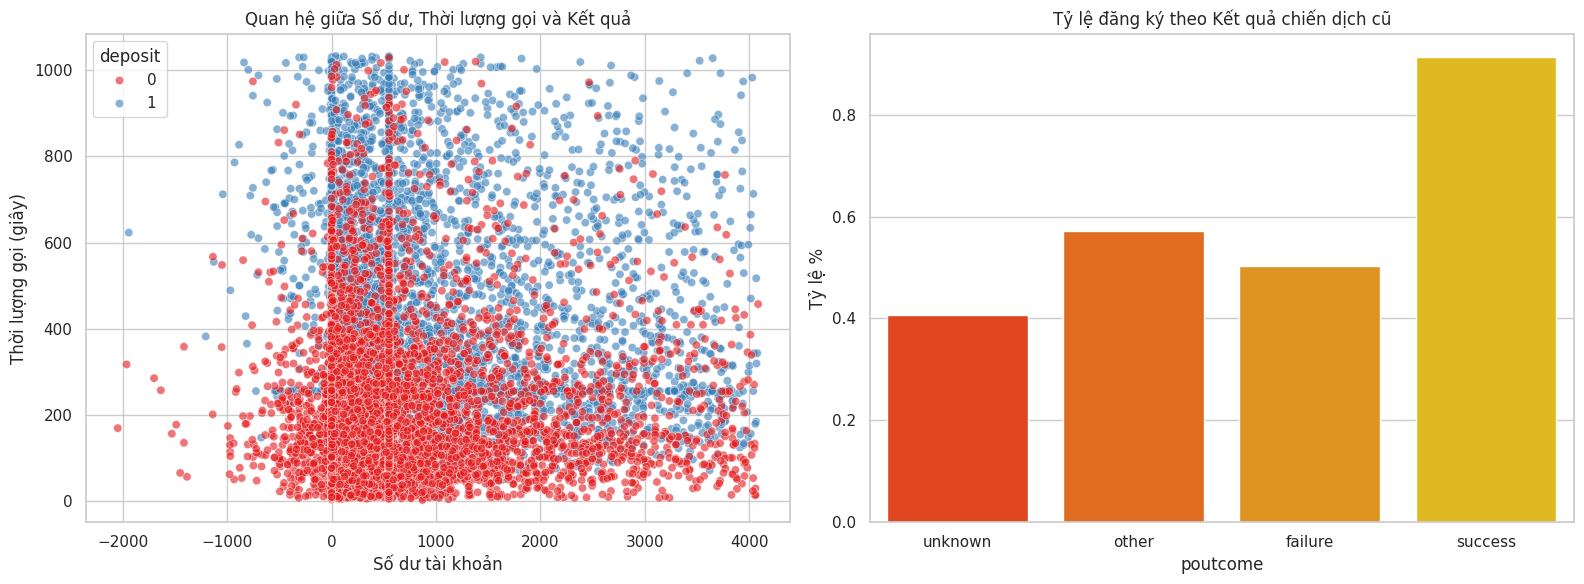

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Scatter Plot: Balance vs Duration (Phân loại theo Deposit)
sns.scatterplot(x='balance', y='duration', hue='deposit', data=df_clean,
                alpha=0.6, palette='Set1', ax=axes[0])
axes[0].set_title('Quan hệ giữa Số dư, Thời lượng gọi và Kết quả')
axes[0].set_xlabel('Số dư tài khoản')
axes[0].set_ylabel('Thời lượng gọi (giây)')

# 2. Bar Chart: Kết quả chiến dịch trước (poutcome) vs Deposit
sns.barplot(x='poutcome', y='deposit', data=df_clean, errorbar=None, palette='autumn', ax=axes[1], hue='poutcome', legend=False)
axes[1].set_title('Tỷ lệ đăng ký theo Kết quả chiến dịch cũ')
axes[1].set_ylabel('Tỷ lệ %')

plt.tight_layout()
plt.show()

**Scatter Plot**: Trả lời cho giả thuyết "Gọi lâu có chốt được không?". Các điểm màu đỏ (deposit=1) tập trung dầy đặc ở nửa trên của trục Y (Duration cao), bất kể Balance ít hay nhiều. Điều này chứng minh: Kỹ năng giữ chân khách hàng trên điện thoại của Telesale quan trọng hơn cả việc khách hàng đó có giàu hay không.

**Poutcome**: Trả lời giả thuyết "Khách cũ có dễ chốt không?". ĐÚNG. Cột success (thành công ở chiến dịch trước) có tỷ lệ đồng ý ở chiến dịch này cao áp đảo (thường > 60-70%). Ngân hàng nên ưu tiên gọi lại tập khách hàng này.

**Giả thuyết 2.2.3: Về thời điểm (Line Chart)**
Sử dụng Biểu đồ đường (Line Chart) để theo dõi xu hướng thời gian.


--- 2.2.3. Kiểm định giả thuyết: Thời điểm hiệu quả (Timing) ---


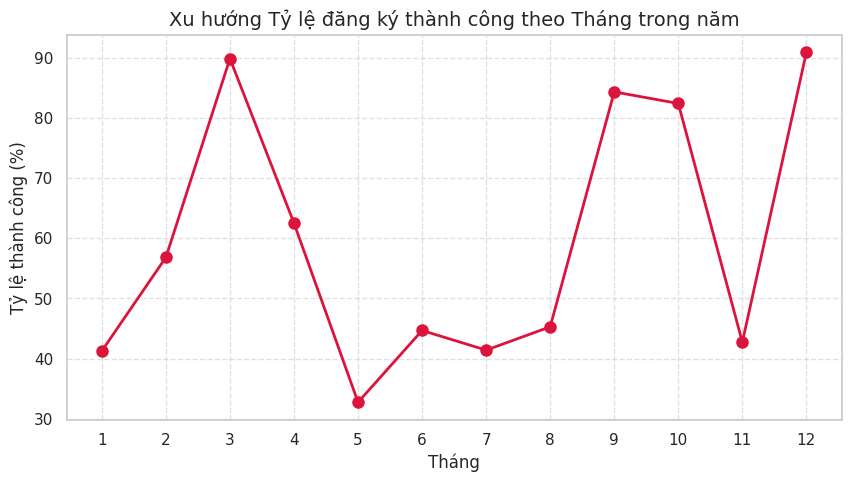

In [22]:
print("\n--- 2.2.3. Kiểm định giả thuyết: Thời điểm hiệu quả (Timing) ---")

# Tính tỷ lệ thành công theo từng tháng
monthly_trend = df_clean.groupby('month_num')['deposit'].mean() * 100

plt.figure(figsize=(10, 5))
# Biểu đồ đường (Line Chart)
plt.plot(monthly_trend.index, monthly_trend.values, marker='o',
         linestyle='-', color='crimson', linewidth=2, markersize=8)

plt.title('Xu hướng Tỷ lệ đăng ký thành công theo Tháng trong năm', fontsize=14)
plt.xlabel('Tháng')
plt.ylabel('Tỷ lệ thành công (%)')
plt.xticks(range(1, 13)) # Đảm bảo hiện đủ 12 tháng
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Biểu đồ này sẽ chỉ ra "Tháng nào hiệu quả nhất?". Thường trong dữ liệu Bank, các tháng đầu năm (tháng 3) hoặc các tháng cuối năm (tháng 9, 10, 12) có tỷ lệ chốt rất cao (đỉnh biểu đồ), trong khi tháng 5 lại chạm đáy. Vậy ngân hàng không nên dồn ngân sách gọi điện vào tháng 5, mà hãy tập trung nguồn lực vào các tháng có đạt chuyển đổi cao nhất.

**2.3 Phân tích tương quan tổng thể (Correlation Matrix)**
Để chốt lại, ta xem xét một bức tranh toán học tổng thể xem biến nào thực sự tác động mạnh nhất đến deposit

\n--- 2.3. Ma trận tương quan (Correlation Matrix) ---


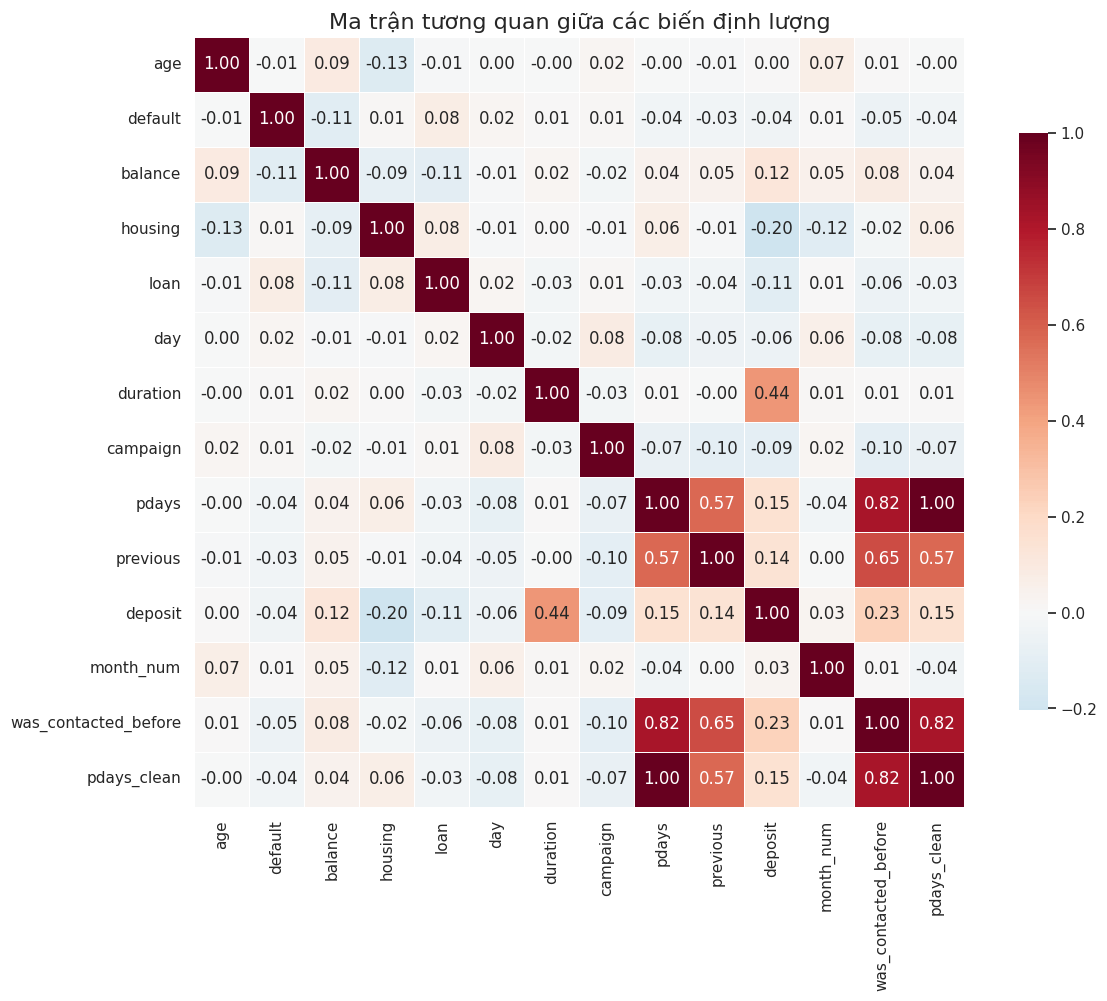

In [23]:
print("\\n--- 2.3. Ma trận tương quan (Correlation Matrix) ---")

# Lọc ra các cột có kiểu dữ liệu là số (numerical)
numeric_df = df_clean.select_dtypes(include=[np.number])

# Tính ma trận tương quan Pearson
corr_matrix = numeric_df.corr()

# Vẽ Heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='RdBu_r', center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .75})
plt.title('Ma trận tương quan giữa các biến định lượng', fontsize=16)
plt.show()

Biến duration sẽ có màu xanh đậm nhất (tương quan dương mạnh nhất): Thời gian gọi quyết định thành công.

Biến campaign (số lần gọi) sẽ có màu nhạt hoặc hơi đỏ (tương quan âm nhẹ): Gọi (spam) càng nhiều trong một chiến dịch, khách hàng càng dễ từ chối. Trả lời trực tiếp cho giả thuyết 2.2.2.

Biến pdays_clean và previous cũng sẽ cho thấy tương quan dương nhất định, củng cố giả thuyết khách cũ dễ tính hơn khách mới.

# 3. ĐÁNH GIÁ BẰNG BIỂU ĐỒ (Visual Analysis)

**3.1. Biểu đồ cột (Bar Chart)**: So sánh hiệu suất giữa các danh mục

\n--- 3.1. Biểu đồ cột: So sánh hiệu suất theo Nghề nghiệp (Job) ---


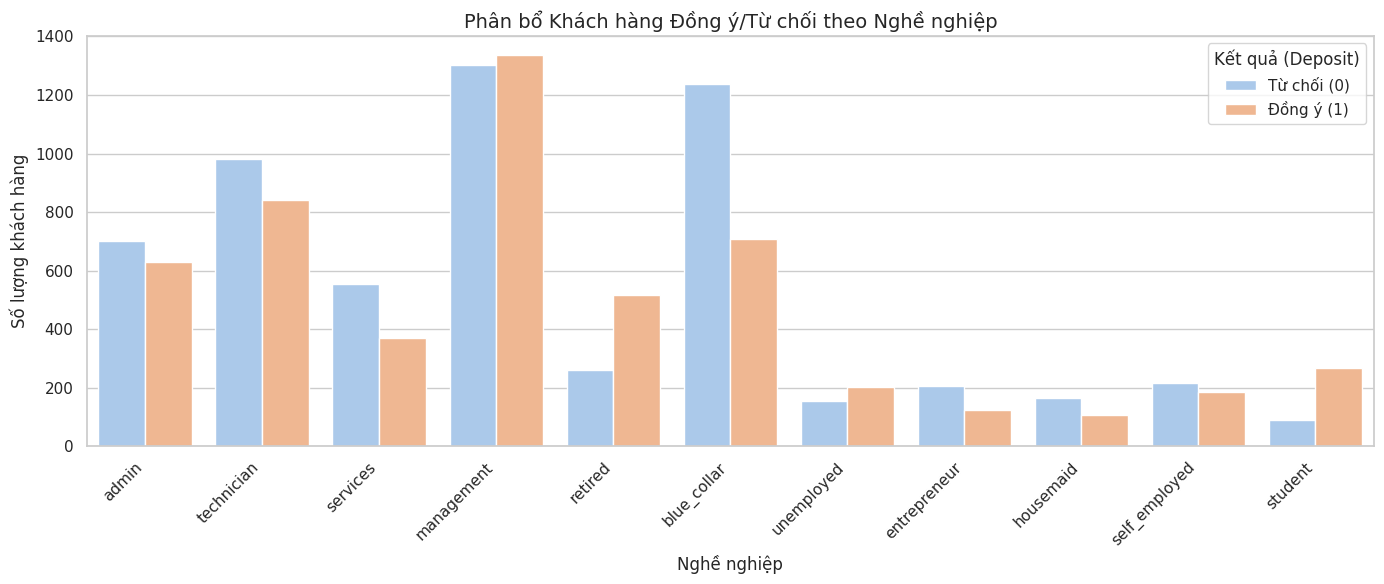

In [24]:
print("\\n--- 3.1. Biểu đồ cột: So sánh hiệu suất theo Nghề nghiệp (Job) ---")

plt.figure(figsize=(14, 6))
# Sử dụng countplot kết hợp hue='deposit' để xem phân bổ Đồng ý/Từ chối trong từng nhóm nghề
sns.countplot(x='job', hue='deposit', data=df_clean, palette='pastel')
plt.title('Phân bổ Khách hàng Đồng ý/Từ chối theo Nghề nghiệp', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Nghề nghiệp')
plt.ylabel('Số lượng khách hàng')
plt.legend(title='Kết quả (Deposit)', labels=['Từ chối (0)', 'Đồng ý (1)'])
plt.tight_layout()
plt.show()

Biểu đồ này chỉ ra tệp khách hàng lõi của ngân hàng. Mặc dù nhóm management (quản lý) và blue-collar (công nhân) có thể có tổng số lượng gọi nhiều nhất, nhưng tỷ lệ cột màu cam (Đồng ý) so với cột màu xanh (Từ chối) ở nhóm student (học sinh) hoặc retired (nghỉ hưu) lại chiếm ưu thế.

# 3.2. Biểu đồ tán xạ (Scatter Plot): Mối quan hệ giữa hai biến định lượng

\n--- 3.2. Biểu đồ tán xạ: Quan hệ giữa Số dư (Balance) và Thời lượng (Duration) ---


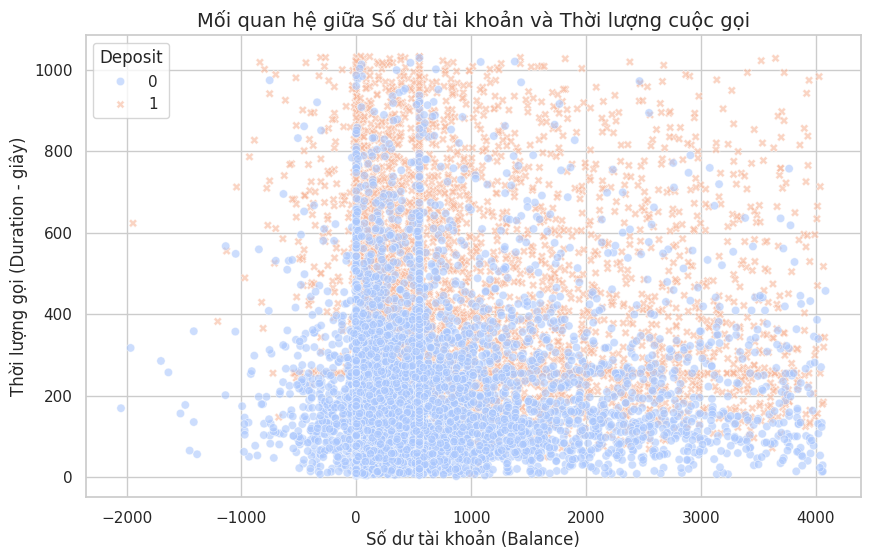

In [25]:
print("\\n--- 3.2. Biểu đồ tán xạ: Quan hệ giữa Số dư (Balance) và Thời lượng (Duration) ---")

plt.figure(figsize=(10, 6))
# Vẽ scatter plot, màu sắc (hue) đại diện cho kết quả gửi tiền
sns.scatterplot(x='balance', y='duration', hue='deposit', style='deposit',
                data=df_clean, alpha=0.6, palette='coolwarm')
plt.title('Mối quan hệ giữa Số dư tài khoản và Thời lượng cuộc gọi', fontsize=14)
plt.xlabel('Số dư tài khoản (Balance)')
plt.ylabel('Thời lượng gọi (Duration - giây)')
plt.legend(title='Deposit')
plt.show()

Giúp ta phát hiện xem có sự tương tác chéo nào không. Ví dụ: Những điểm màu đỏ (deposit=1) thường nằm ở nửa trên của trục Y (thời lượng cao), trải dài trên nhiều mức balance. Nó chứng minh rằng: Dù khách hàng có ít hay nhiều tiền trong tài khoản, chỉ cần tư vấn viên giữ chân họ trên điện thoại đủ lâu, tỷ lệ chốt sale sẽ tăng cao.

# 3.3. Biểu đồ đường (Line Chart): Theo dõi xu hướng thời gian

\n--- 3.3. Biểu đồ đường: Xu hướng tỷ lệ gửi tiền theo Tháng ---


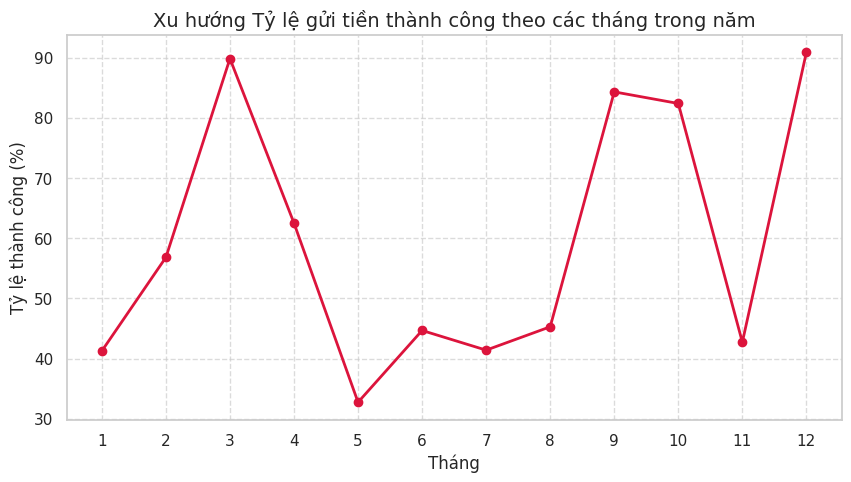

In [26]:
print("\\n--- 3.3. Biểu đồ đường: Xu hướng tỷ lệ gửi tiền theo Tháng ---")

# Nhóm dữ liệu theo tháng (dùng month_num để sắp xếp theo thứ tự 1-12)
monthly_trend = df_clean.groupby('month_num')['deposit'].mean() * 100

plt.figure(figsize=(10, 5))
plt.plot(monthly_trend.index, monthly_trend.values, marker='o', linestyle='-', color='crimson', linewidth=2)

plt.title('Xu hướng Tỷ lệ gửi tiền thành công theo các tháng trong năm', fontsize=14)
plt.xlabel('Tháng')
plt.ylabel('Tỷ lệ thành công (%)')
plt.xticks(range(1, 13)) # Đảm bảo trục X hiển thị từ tháng 1 đến 12
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Biểu đồ này bóc tách "tính mùa vụ" (Seasonality) của chiến dịch Marketing. Thường ta sẽ thấy các đỉnh (peaks) vào các tháng đầu năm (tháng 3) hoặc cuối năm (tháng 9, 10, 12). Sự sụt giảm ở các tháng giữa năm (tháng 5) cho thấy ngân hàng đang lãng phí nguồn lực gọi điện vào thời điểm khách hàng không có nhu cầu. Đề xuất: Phân bổ lại ngân sách Telesale vào các tháng có Tỷ lệ thành công cao.